# Stairs Up, Elevator Down 🛗 — the machinery
### First passage, Ramsey-Rothman, skew by horizon, a leverage mechanism check, and a pre-registered rule

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

The S&P 500 path is time-irreversible at robust t = -3.39 (block bootstrap
-4.04), in the leverage direction, and a fitted GJR-GARCH reproduces ~72%
of it while symmetric GARCH and i.i.d. reproduce none. But the literal proverb fails: the first
10% off a trough is covered faster than the first 10% off a peak (elevator ratio
0.73×, sign-flip p = 0.010 in the reverse tail). The pre-registered
fast-exit / slow-entry rule loses to buy-and-hold on both daily tapes after costs.

> 📓 Companion: **[01_for_the_curious.ipynb](01_for_the_curious.ipynb)**. Headline run:
> [`docs/results.md`](../docs/results.md). ⚠️ **Not investment advice.**

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.2)
plt.rcParams["figure.dpi"] = 80
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
pd.set_option("display.width", 160)
from stairs import data, strategy as st
UP, DOWN, GREY = "#2ea44f", "#c0392b", "#8b949e"

In [2]:
sp, nq, ff = data.load_sp500(), data.load_nasdaq(), data.load_ff_market()
fi = data.ff_index(ff)
r_sp, r_nq = st.log_returns(sp).to_numpy(), st.log_returns(nq).to_numpy()
r_ff = np.log(fi).diff().dropna().to_numpy()
for k, v in data.PROVENANCE.items():
    print(f"{k:7s} {v['package']:38s} {v['tape']:12s} {v['kind']:52s} sha256 {v['sha256'][:12]}")
print(f"fingerprints: sp {data.fingerprint(sp)}  nq {data.fingerprint(nq)}  ff {data.fingerprint(ff)}")
print(f"S&P {sp.index[0].date()}→{sp.index[-1].date()} | Nasdaq {nq.index[0].date()}→"
      f"{nq.index[-1].date()} | FF {ff.index[0]:%Y-%m}→{ff.index[-1]:%Y-%m}")

sp500   skfolio 1.8.1 (pinned wheel, cached)   sp500_index  daily price index (no dividends)                     sha256 894c34431c28
nasdaq  arch                                   nasdaq       daily price index (no dividends)                     sha256 b2009535343e
ff      arch                                   frenchdata   monthly total return (dividends included), decimal   sha256 f23436727b01
fingerprints: sp e223c581ae22  nq 8478f8bf44dd  ff c7f1e4140bfb
S&P 1990-01-02→2022-11-30 | Nasdaq 1999-01-04→2018-12-31 | FF 1926-07→2018-11


## 1 · The claim, formally

Let `p_t` be the log index. The proverb is a statement about the joint law of the path, not its
marginal: `(p_1, …, p_T)` and `(p_T, …, p_1)` differ in distribution (**time irreversibility**),
and the difference has a direction — conditional on a move of a given size, declines are covered
in less time than advances. Negative skewness is neither necessary nor sufficient: an i.i.d.
skewed process is time-reversible, and a sign-symmetric process with a leverage term is not.

Two operational readings, both tested:

1. **First passage.** Inside zig-zag legs at a log-symmetric reversal `h = log(1+X)`, the
   geometric-mean time to traverse `+h` from a trough vs `−h` from a peak. Ratio > 1 = elevator.
2. **Ramsey-Rothman (1996).** On standardised returns `x`, `TR(k) = E[x_t² x_{t−k}] − E[x_t x_{t−k}²]`,
   zero for every k under reversibility, sign-flipped by reversal.

## 2 · So what?

A reliably faster downside would (i) make symmetric risk budgets understate the speed of
losses, (ii) rationalise the index put skew, and (iii) suggest an asymmetric timing rule: exits
must be fast, entries can afford to wait. (iii) is the only claim that pays a holder directly,
and it is the one that has to survive one lag and costs.

## 3 · How we'd know — pre-registered

`strategy.verdict`, fixed before the real run and unit-tested both ways:

| | Condition |
|---|---|
| `tr_ok` | TR sum (K = 10, S&P 500 daily) < 0 with NW t ≤ −2 **and** block-bootstrap t ≤ −2 |
| `dur_ok` | 10% elevator ratio > 1 with sign-flip Monte Carlo p < 0.05 |
| Signal | **Real** both · **Mixed** exactly one · **Weak** neither but both point the elevator way · **None** otherwise |
| Investable | FF 1926-2018: rule beats B&H on net excess Sharpe at p < 0.05 **and** beats its 5%/5% twin, **and** net edge > 0 on both daily tapes |
| Fragile | net edge > 0 on ≥ 2 of 3 tapes |
| Mirage | otherwise |

Nulls: **sign-flip** (keep `|r_t − μ|`, the drift and the volatility clustering; randomise signs
— kills all sign asymmetry) and **permutation** (keep each day, destroy the order — kills
irreversibility, keeps marginal skew).

## 4 · The teardown

### 4.1 First passage: time to gain X% vs time to lose X%

In [3]:
rows = []
for name, r in (("S&P 500", r_sp), ("Nasdaq", r_nq), ("FF monthly", r_ff)):
    lp = np.concatenate([[0.0], np.cumsum(r)])
    for x in st.THRESHOLDS:
        s = st.leg_stats(lp, x)
        rows.append({"tape": name, "X": x, "n_up": s["n_up"], "n_down": s["n_down"],
                     "gm_up": s["gm_up"], "gm_down": s["gm_down"],
                     "elevator": s["elevator_ratio"], "speed_ratio": s["speed_ratio"]})
legs_tbl = pd.DataFrame(rows).set_index(["tape", "X"])
legs_tbl

n_up  n_down  gm_up  gm_down  elevator  speed_ratio
tape       X                                                         
S&P 500    0.050   123     123  5.814    8.037     0.723        1.493
           0.100    33      33 13.437   18.474     0.727        1.763
           0.200    10      11 31.385   52.970     0.592        2.726
Nasdaq     0.050   122     121  3.678    4.923     0.747        1.086
           0.100    40      40  9.924   12.091     0.821        1.253
           0.200    12      12 26.810   54.459     0.492        1.494
FF monthly 0.050    88      88  1.420    1.655     0.858        1.416
           0.100    38      37  2.367    3.090     0.766        1.357
           0.200    18      17  4.832    4.432     1.090        2.182

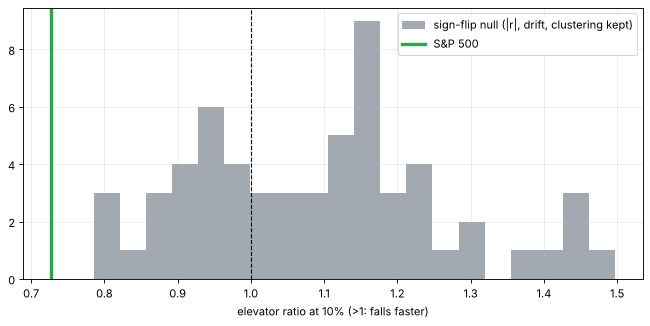

In [4]:
# sign-flip null for the S&P 500 at 10% (fewer replications than verify.py — shape, not p-values)
t = st.leg_null_test(r_sp, xs=(0.10,), kind="signflip", n_rep=60, seed=1016)
lp0 = np.concatenate([[0.0], np.cumsum(r_sp)])
null = [st.leg_stats(p, 0.10)["elevator_ratio"] for p in st._null_paths(r_sp, "signflip", 60, 1016)]
fig, ax = plt.subplots(figsize=(10, 4.4))
ax.hist(null, bins=20, color=GREY, alpha=0.8, label="sign-flip null (|r|, drift, clustering kept)")
ax.axvline(t.loc[0.10, "elevator_ratio"], color=UP, lw=3, label="S&P 500")
ax.axvline(1.0, color="k", ls="--", lw=1)
ax.set_xlabel("elevator ratio at 10% (>1: falls faster)"); ax.legend(); plt.show()

> 💡 **In plain words.** Grey: worlds with the same day sizes, the same calm and stormy
> spells and the same drift, but random up/down signs. Green: the real tape. It sits on the
> *fast-rebound* side of almost every fake world.

From `verify.py` (200 sign-flip paths): elevator ratio 0.73× at 10%
(0.72× at 5%, 0.59× at 20%); elevator-direction p = 0.995, reverse
p = 0.010. Nasdaq 0.82×, FF monthly 0.77×. The permutation
null (skew kept, order destroyed) also sits above 1, so the real tape's rebound speed is an
*order* effect.

### 4.2 The completed leg — the steelman's best reading

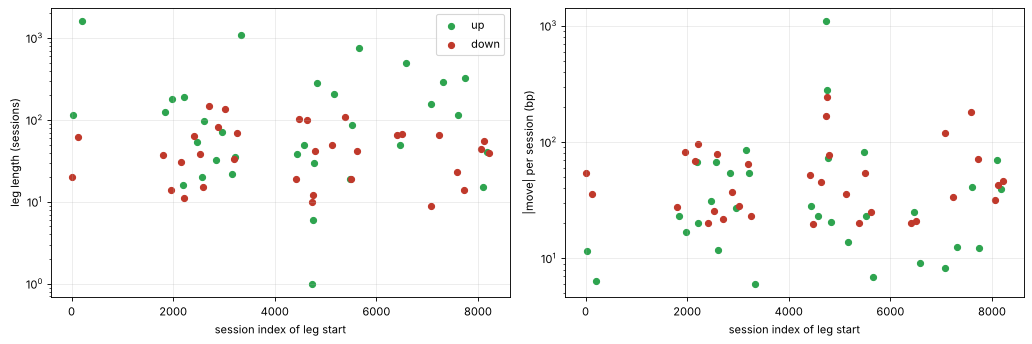

     dur_days  speed_bp
dir                    
-1     42.000    42.471
 1     79.500    24.092


In [5]:
L = st.legs(lp0, np.log1p(0.10)).dropna(subset=["dur_days"])
L["speed_bp"] = L["move"].abs() / L["dur_days"] * 1e4
fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
for d, c in ((1, UP), (-1, DOWN)):
    f = L[L["dir"] == d]
    ax[0].scatter(f["start"], f["dur_days"], color=c, s=30, label="up" if d == 1 else "down")
    ax[1].scatter(f["start"], f["speed_bp"], color=c, s=30)
ax[0].set_yscale("log"); ax[0].set_ylabel("leg length (sessions)"); ax[0].legend()
ax[1].set_yscale("log"); ax[1].set_ylabel("|move| per session (bp)")
for a in ax: a.set_xlabel("session index of leg start")
plt.tight_layout(); plt.show()
print(L.groupby("dir")[["dur_days", "speed_bp"]].median())

Completed declines are shorter and steeper: median-speed ratio 1.76× at 10% (sign-flip
p = 0.07) and 1.49× at 5% (p = 0.01). This is the reading the
proverb survives on — but it is a statement about how long bull legs last, which the drift and
the zig-zag's end-point selection both feed, not about how quickly a given distance is covered.

> 💡 **In plain words.** "The whole climb took two years, the whole fall took two months"
> is true. "The first 10% down is quicker than the first 10% back up" is false.

### 4.3 Ramsey-Rothman time reversibility, three tapes

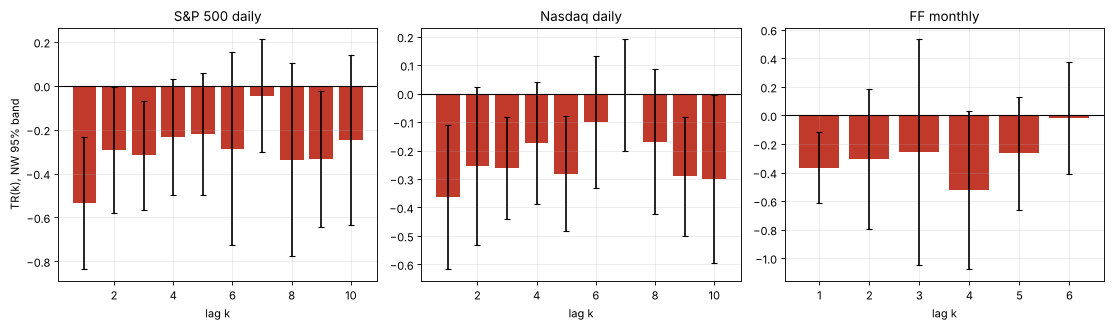

,TR sum,NW t,boot t,reversed
S&P 500 daily,-2.848,-3.389,-3.849,2.848
Nasdaq daily,-2.198,-3.631,-4.640,2.167
FF monthly,-1.736,-1.877,-2.441,1.739


In [6]:
res = {"S&P 500 daily": st.tr_stats(r_sp, 10, n_boot=300, block=20),
       "Nasdaq daily": st.tr_stats(r_nq, 10, n_boot=300, block=20),
       "FF monthly": st.tr_stats(r_ff, 6, n_boot=300, block=6)}
fig, ax = plt.subplots(1, 3, figsize=(14, 4.2), sharey=False)
for a, (k, v) in zip(ax, res.items()):
    pl = v["per_lag"]
    se = pl["tr"] / pl["t_nw"]
    a.bar(pl.index, pl["tr"], color=DOWN, yerr=1.96 * se.abs(), capsize=3)
    a.axhline(0, color="k", lw=1); a.set_title(k); a.set_xlabel("lag k")
ax[0].set_ylabel("TR(k), NW 95% band"); plt.tight_layout(); plt.show()
pd.DataFrame({k: {"TR sum": v["tr_sum"], "NW t": v["t_nw"], "boot t": v["t_boot"],
                  "reversed": v["tr_sum_reversed"]} for k, v in res.items()}).T

Headline (1,000 block-bootstrap draws in `verify.py`): S&P 500 TR sum -2.85, NW t =
-3.39, block-bootstrap t = -4.04; with the 0.5% tails clipped t =
-5.19 — so it is not three crash days. Weekly -2.76; Nasdaq -3.63;
FF monthly -1.88 (bootstrap -2.56). `tr_ok` holds.

> 💡 **In plain words.** Negative TR(k) means a down day is followed by bigger moves
> (either way) than an up day is. That is the leverage effect, and it is what makes the film look
> different backwards.

### 4.4 Skewness by horizon — the weaker witness

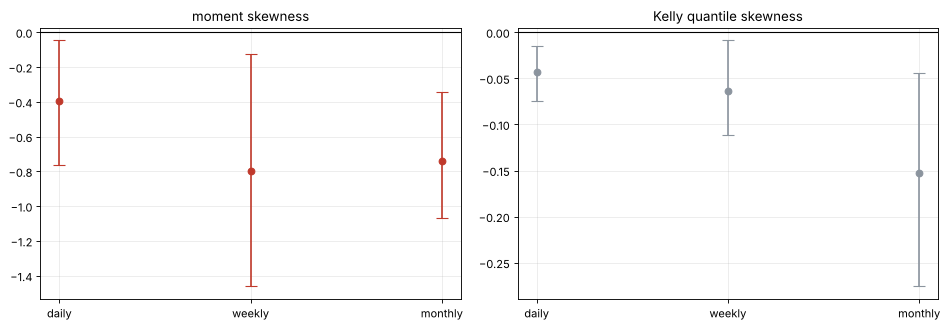

,n,block,skew,skew_lo,skew_hi,kelly,kelly_lo,kelly_hi
series,,,,,,,,
daily,8293,21,-0.396,-0.764,-0.044,-0.043,-0.074,-0.014
weekly,1717,8,-0.795,-1.462,-0.124,-0.063,-0.112,-0.008
monthly,394,6,-0.739,-1.066,-0.345,-0.153,-0.276,-0.045


In [7]:
lsp = np.log(sp)
ser = {"daily": r_sp, "weekly": st.aggregate(lsp, "W-FRI").to_numpy(),
       "monthly": st.aggregate(lsp, "ME").to_numpy()}
sk = st.skew_table(ser, {"daily": 21, "weekly": 8, "monthly": 6}, n_boot=300)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
xs = np.arange(len(sk))
ax[0].errorbar(xs, sk["skew"], yerr=[sk["skew"] - sk["skew_lo"], sk["skew_hi"] - sk["skew"]],
               fmt="o", color=DOWN, capsize=5)
ax[1].errorbar(xs, sk["kelly"], yerr=[sk["kelly"] - sk["kelly_lo"], sk["kelly_hi"] - sk["kelly"]],
               fmt="o", color=GREY, capsize=5)
for a, t in zip(ax, ("moment skewness", "Kelly quantile skewness")):
    a.axhline(0, color="k", lw=1); a.set_xticks(xs); a.set_xticklabels(sk.index); a.set_title(t)
plt.tight_layout(); plt.show()
sk

S&P 500 daily skew -0.40 [-0.76, -0.05], monthly -0.74 [-1.07, -0.36]
(block-bootstrap 95%). The Nasdaq daily and FF monthly intervals straddle zero (see
`docs/results.md`). Kelly skew is small and *negative* (-0.043 daily): the "many small
steps up" picture would need it positive. Skewness carries no information about order.

### 4.5 Mechanism — GJR / EGARCH vs symmetric GARCH vs i.i.d.

In [8]:
fits = st.fit_models(r_sp)
pd.DataFrame(fits).T

,mu,omega,alpha,beta,nu,gamma,gamma_t,loglik
garch,0.072,0.011,0.101,0.896,6.130,0.000,NaN,"-10,868.991"
gjr,0.048,0.015,0.002,0.898,6.692,0.173,9.552,"-10,759.538"
egarch,0.045,-0.001,0.149,0.981,6.725,-0.136,-13.759,"-10,739.297"


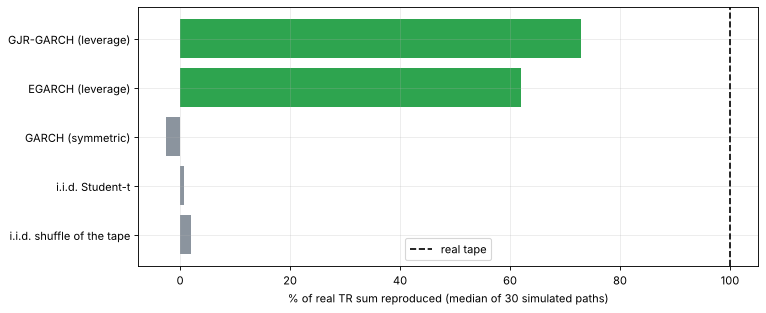

,tr_sum,skew_monthly,elevator_ratio,share_tr,share_elevator
world,,,,,
REAL TAPE,-2.848,-0.795,0.727,1.000,1.000
GJR-GARCH (leverage),-2.079,-1.009,0.735,0.730,0.966
EGARCH (leverage),-1.763,-0.953,0.711,0.619,1.072
GARCH (symmetric),0.071,-0.304,1.121,-0.025,-0.358
i.i.d. Student-t,-0.021,-0.008,0.974,0.007,0.084
i.i.d. shuffle of the tape,-0.059,-0.082,1.171,0.021,-0.496


In [9]:
mc = st.mechanism_check(r_sp, fits, n_paths=30, seed=1016)
show = mc[["tr_sum", "skew_monthly", "elevator_ratio", "share_tr", "share_elevator"]]
fig, ax = plt.subplots(figsize=(10, 4.2))
w = show.drop(index="REAL TAPE")
ax.barh(w.index[::-1], 100 * w["share_tr"][::-1],
        color=[UP if "leverage" in i else GREY for i in w.index[::-1]])
ax.axvline(100, color="k", ls="--", label="real tape"); ax.legend()
ax.set_xlabel("% of real TR sum reproduced (median of 30 simulated paths)"); plt.show()
show

`verify.py` (100 paths per world): GJR 72% of the TR sum, EGARCH
65%, symmetric GARCH 6%, i.i.d. 0%. The
GJR leverage term is t = +9.6. The GJR world also reproduces the *reversed*
elevator ratio (106% of its log): leverage puts peak volatility at the trough, so
the first leg up is fast — the mechanism explains the anti-proverb too.

> 💡 **In plain words.** The only fake markets that look like the real one are those where
> falls make the market jumpier. Markets that are merely "sometimes calm, sometimes stormy" don't.

### 4.6 Positive control — the planted world *(synthetic, not market evidence)*

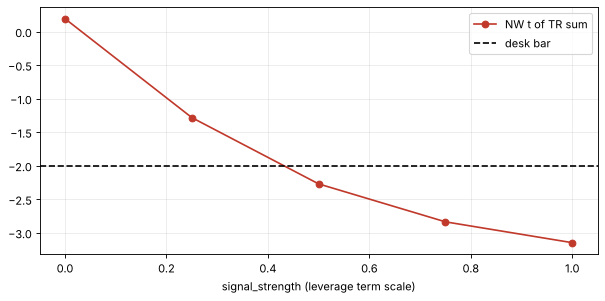

,gamma,TR sum,NW t,boot t,elevator 5%
signal_strength,,,,,
0.000,0.000,0.051,0.193,0.226,0.925
0.250,0.037,-0.360,-1.282,-1.442,0.859
0.500,0.075,-0.755,-2.271,-2.457,0.830
0.750,0.112,-1.153,-2.836,-2.987,0.762
1.000,0.150,-1.561,-3.147,-3.276,0.711


In [10]:
rows = []
for s in (0.0, 0.25, 0.5, 0.75, 1.0):
    df, truth = data.synthetic_returns(8000, s, seed=1016)
    tr = st.tr_stats(df["logret"].to_numpy(), 10, n_boot=100)
    rows.append({"signal_strength": s, "gamma": truth["gamma_eff"], "TR sum": tr["tr_sum"],
                 "NW t": tr["t_nw"], "boot t": tr["t_boot"],
                 "elevator 5%": st.leg_stats(np.log(df["price"].to_numpy()), 0.05)["elevator_ratio"]})
ctl = pd.DataFrame(rows).set_index("signal_strength")
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ctl.index, ctl["NW t"], "o-", color=DOWN, label="NW t of TR sum")
ax.axhline(-2, color="k", ls="--", label="desk bar"); ax.legend()
ax.set_xlabel("signal_strength (leverage term scale)"); plt.show()
ctl

> 💡 **In plain words.** With the leverage term switched off (0.0) the detector is quiet;
> switched on, it fires. That proves the machinery can see the effect — it says nothing about the
> market, which is what sections 4.1-4.5 are for.

## 5 · The verdict

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

`tr_ok` = True (t = -3.39, bootstrap -4.04); `dur_ok` = False (elevator
ratio 0.73× < 1). Exactly one → **Mixed**: the path is irreversible in the leverage
direction; the literal "same distance, faster down" reading is reversed.

## 6 · Could you trade it?

In [11]:
races = {}
sp_t, nq_t = (s[s.index <= pd.Timestamp(data.FF_AS_OF)] for s in (sp, nq))
races["S&P 500 daily"] = st.race(sp_t, data.daily_rf(sp_t.index, ff), 0.0005, n_boot=200)
races["Nasdaq daily"] = st.race(nq_t, data.daily_rf(nq_t.index, ff), 0.0005, n_boot=200)
races["FF monthly TR"] = st.race(fi, ff["rf"].reindex(fi.index).fillna(0.0), 0.0010,
                                 periods=12, block=6, n_boot=200)
tbl = pd.concat({k: v[["sharpe_gross", "sharpe_net", "sharpe_bh", "d_vs_bh", "p_vs_bh",
                       "time_in", "trades_per_year"]] for k, v in races.items()})
tbl

sharpe_gross  sharpe_net  sharpe_bh  d_vs_bh  p_vs_bh  time_in  trades_per_year
              rule                                                                                                            
S&P 500 daily fast-exit/slow-entry (5% / 10%)         0.055       0.037      0.336   -0.299    0.975    0.509            3.562
              symmetric (5% / 5%)                    -0.021      -0.046      0.336   -0.382    0.995    0.791            6.536
              symmetric (10% / 10%)                   0.354       0.348      0.336    0.012    0.485    0.845            1.556
Nasdaq daily  fast-exit/slow-entry (5% / 10%)         0.104       0.080      0.296   -0.216    0.870    0.512            6.688
              symmetric (5% / 5%)                     0.127       0.096      0.296   -0.201    0.940    0.728           11.265
              symmetric (10% / 10%)                   0.342       0.333      0.296    0.036    0.445    0.761            3.470
FF monthly TR fast-exit/slow-entry (5% / 10%)         0.581       0.570      0.429    0.141    0.050    0.648            1.331
              symmetric (5% / 5%)                     0.513       0.500      0.429    0.071    0.200    0.757            1.829
              symmetric (10% / 10%)                   0.556       0.551      0.429    0.122    0.045    0.816            0.714

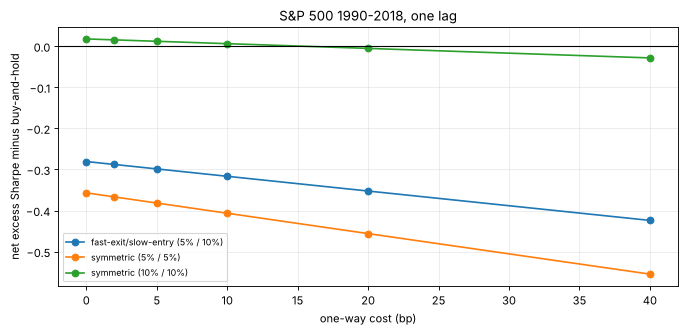

In [12]:
costs = [0, 2, 5, 10, 20, 40]
fig, ax = plt.subplots(figsize=(10, 4.2))
for name, (ex, en) in st.RULES.items():
    sig = st.zigzag_rule(sp_t, ex, en)
    d = [st.backtest(sp_t, data.daily_rf(sp_t.index, ff), sig, c / 1e4)["sharpe_net"]
         - st.backtest(sp_t, data.daily_rf(sp_t.index, ff), sig, 0)["sharpe_bh"] for c in costs]
    ax.plot(costs, d, "o-", label=name)
ax.axhline(0, color="k", lw=1); ax.set_xlabel("one-way cost (bp)")
ax.set_ylabel("net excess Sharpe minus buy-and-hold"); ax.set_title("S&P 500 1990-2018, one lag")
ax.legend(fontsize=8); plt.show()

Headline (`verify.py`, 500 paired block-bootstrap draws): net Sharpe edge of the pre-registered
5%/10% rule over buy-and-hold **-0.30** on the S&P 500, **-0.22** on the Nasdaq (both
price-only, which flatters a rule that holds cash), **+0.14** on FF 1926-2018 (p =
0.03) shrinking to +0.08 (p = 0.23) after 1945. The symmetric 10%/10% twin
matches it on FF (+0.12), so the asymmetry is not the source of whatever a drawdown
rule earns. Only one of three tapes positive → **Mirage**.

Even at zero cost the asymmetric rule loses on daily data: the cost of a slow re-entry is
missing the fastest move on the tape, the rebound off the low — the section 4.1 finding, priced.

> 💡 **In plain words.** Knowing that the market is lopsided in time tells you what
> insurance should cost. It doesn't tell you when to sell.

## 7 · Going further

- **Option-implied check.** Map the realised TR statistic, rolling, against the slope of the
  index implied-vol skew (needs an options tape the desk does not ship).
- **Intraday first passage.** At 5-minute resolution the fast-rebound effect should be visible
  inside single sessions if volatility feedback is the mechanism.
- **Cross-section.** Single stocks have positive skew but may still be leverage-irreversible —
  a cleaner separation of skew from order than an index allows.
- **Conditional rules.** A rule that *re-enters fast when volatility is high* (the opposite of
  slow entry) is the trade this study's mechanism suggests; it would need its own
  pre-registration and a fresh tape.